# Лабораторная работа №3
## Классификация временных рядов и прогнозирование метеоданных шести городов России

Задача состоит из двух этапов: сначала определяем к какому типу климата относится поступающий временной ряд метеоданных, потом применяем подходящую прогнозную модель для этого типа.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from scipy import stats

from sktime.classification.kernel_based import RocketClassifier

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
print('Все библиотеки загружены')

Все библиотеки загружены


In [2]:
DATA_DIR = 'данные'
CITIES = ['Москва', 'Санкт-Петербург', 'Сочи', 'Геленджик', 'Благовещенск', 'Находка']
FEATURES = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
            'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

# типы климата - 3 класса по 2 города
CLIMATE_LABELS = {
    'Сочи': 0, 'Геленджик': 0,
    'Москва': 1, 'Санкт-Петербург': 1,
    'Благовещенск': 2, 'Находка': 2
}
CLIMATE_NAMES = {0: 'Черноморский', 1: 'Умеренно-конт.', 2: 'Дальневосточный'}
CITY_COLORS = {'Москва': 'steelblue', 'Санкт-Петербург': 'royalblue',
               'Сочи': 'tomato', 'Геленджик': 'salmon',
               'Благовещенск': 'forestgreen', 'Находка': 'mediumseagreen'}

print('Загружаем данные...')
dfs = {}
for city in CITIES:
    files = sorted(glob.glob(f'{DATA_DIR}/{city}_*.parquet'))
    dfs[city] = pd.concat([pd.read_parquet(f) for f in files]).sort_index()

print(f'Загружено {len(CITIES)} городов:')
for city in CITIES:
    d = dfs[city]
    print(f'  {city}: {d.shape[0]:,} часов, {d.index[0].date()} - {d.index[-1].date()}, NaN: {d.isnull().sum().sum()}')

Загружаем данные...
Загружено 6 городов:
  Москва: 61,368 часов, 2019-01-01 - 2025-12-31, NaN: 0
  Санкт-Петербург: 61,368 часов, 2019-01-01 - 2025-12-31, NaN: 0
  Сочи: 61,368 часов, 2019-01-01 - 2025-12-31, NaN: 0
  Геленджик: 61,368 часов, 2019-01-01 - 2025-12-31, NaN: 0
  Благовещенск: 61,368 часов, 2019-01-01 - 2025-12-31, NaN: 0
  Находка: 61,368 часов, 2019-01-01 - 2025-12-31, NaN: 0


## 2.1 Разведочный анализ данных (EDA)

In [3]:
# базовая статистика по температуре для каждого города
stats_rows = []
for city in CITIES:
    t = dfs[city]['temperature_2m']
    stats_rows.append({
        'Город': city, 'Тип климата': CLIMATE_NAMES[CLIMATE_LABELS[city]],
        'Мин': t.min().round(1), 'Макс': t.max().round(1),
        'Среднее': t.mean().round(1), 'Std': t.std().round(1),
        'NaN': t.isna().sum()
    })

df_stats = pd.DataFrame(stats_rows).set_index('Город')
print('=== Статистика температуры по городам ===')
print(df_stats.to_string())

=== Статистика температуры по городам ===
                     Тип климата        Мин       Макс  Среднее   Std  NaN
Город                                                                     
Москва            Умеренно-конт. -31.000000  34.799999      6.8  10.6    0
Санкт-Петербург   Умеренно-конт. -28.799999  35.700001      6.8   9.6    0
Сочи                Черноморский -11.200000  35.299999     15.0   7.5    0
Геленджик           Черноморский -10.000000  37.799999     14.4   8.5    0
Благовещенск     Дальневосточный -41.900002  35.000000      2.2  16.0    0
Находка          Дальневосточный -26.600000  33.200001      7.0  11.6    0


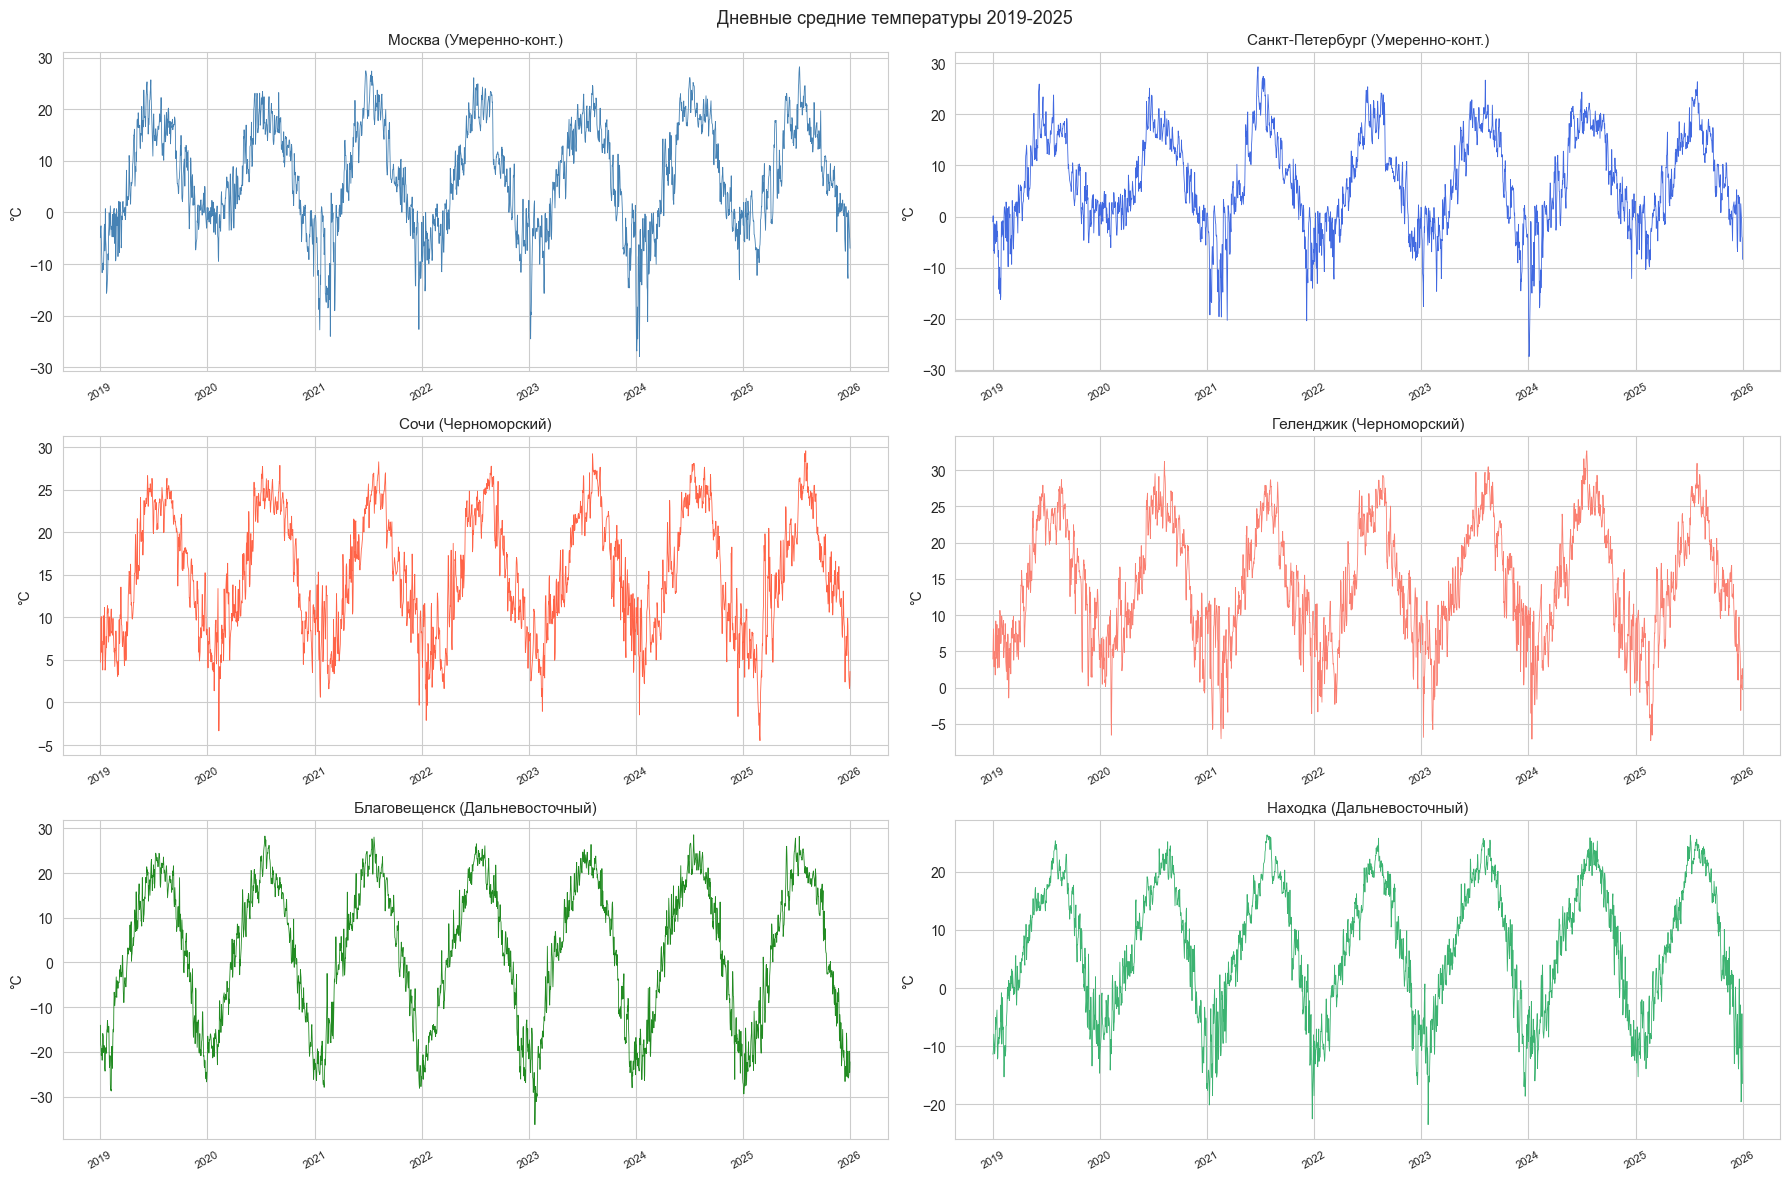

In [4]:
# визуализация температуры всех городов - ресемплируем до дневных для скорости
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()
for i, city in enumerate(CITIES):
    daily_t = dfs[city]['temperature_2m'].resample('D').mean()
    axes[i].plot(daily_t.index, daily_t.values, linewidth=0.6,
                 color=CITY_COLORS[city])
    axes[i].set_title(f'{city} ({CLIMATE_NAMES[CLIMATE_LABELS[city]]})', fontsize=11)
    axes[i].set_ylabel('°C')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
plt.suptitle('Дневные средние температуры 2019-2025', fontsize=13)
plt.tight_layout()
plt.show()

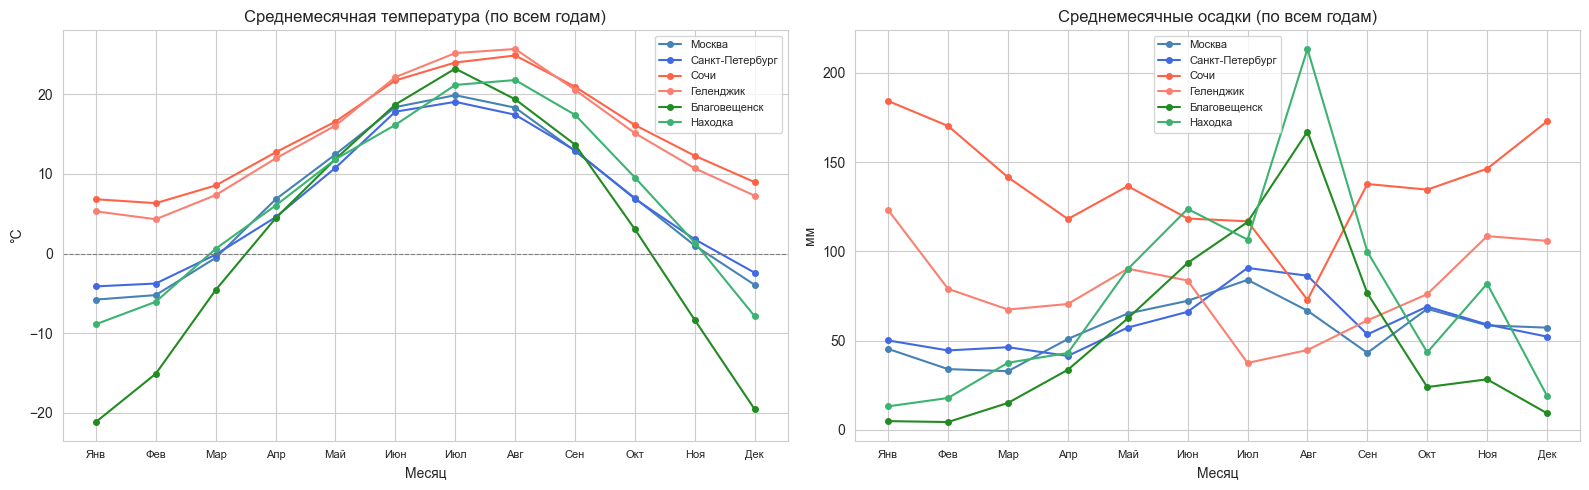

In [5]:
# сезонные паттерны - среднемесячная температура
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# среднемесячная температура
for city in CITIES:
    monthly = dfs[city]['temperature_2m'].resample('ME').mean()
    monthly_avg = monthly.groupby(monthly.index.month).mean()
    axes[0].plot(range(1, 13), monthly_avg.values, marker='o', markersize=4,
                 label=city, color=CITY_COLORS[city], linewidth=1.5)
axes[0].set_title('Среднемесячная температура (по всем годам)')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('°C')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Янв','Фев','Мар','Апр','Май','Июн',
                          'Июл','Авг','Сен','Окт','Ноя','Дек'], fontsize=8)
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

# осадки по месяцам
for city in CITIES:
    monthly_prec = dfs[city]['precipitation'].resample('ME').sum()
    monthly_avg = monthly_prec.groupby(monthly_prec.index.month).mean()
    axes[1].plot(range(1, 13), monthly_avg.values, marker='o', markersize=4,
                 label=city, color=CITY_COLORS[city], linewidth=1.5)
axes[1].set_title('Среднемесячные осадки (по всем годам)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('мм')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Янв','Фев','Мар','Апр','Май','Июн',
                          'Июл','Авг','Сен','Окт','Ноя','Дек'], fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

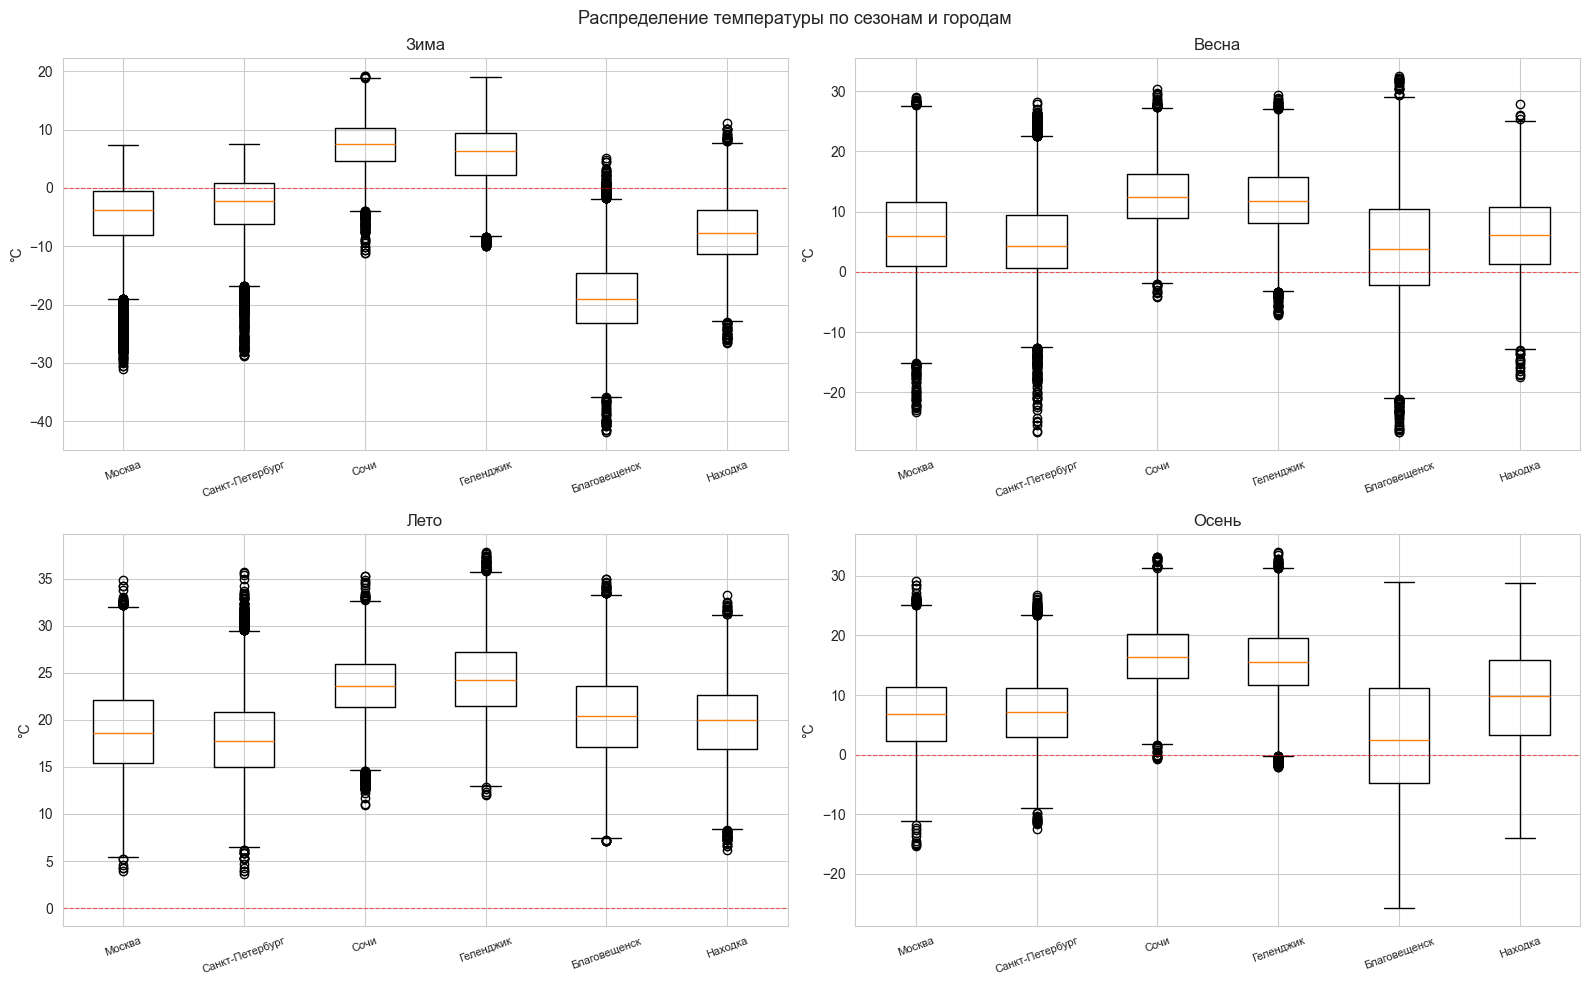

In [6]:
# кросс-городское сравнение температур по сезонам
seasons = {'Зима': [12, 1, 2], 'Весна': [3, 4, 5],
           'Лето': [6, 7, 8], 'Осень': [9, 10, 11]}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (season_name, months) in zip(axes.flatten(), seasons.items()):
    data = []
    labels = []
    for city in CITIES:
        t = dfs[city]['temperature_2m']
        mask = t.index.month.isin(months)
        data.append(t[mask].values)
        labels.append(city)
    ax.boxplot(data, labels=labels)
    ax.set_title(f'{season_name}')
    ax.set_ylabel('°C')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
plt.suptitle('Распределение температуры по сезонам и городам', fontsize=13)
plt.tight_layout()
plt.show()

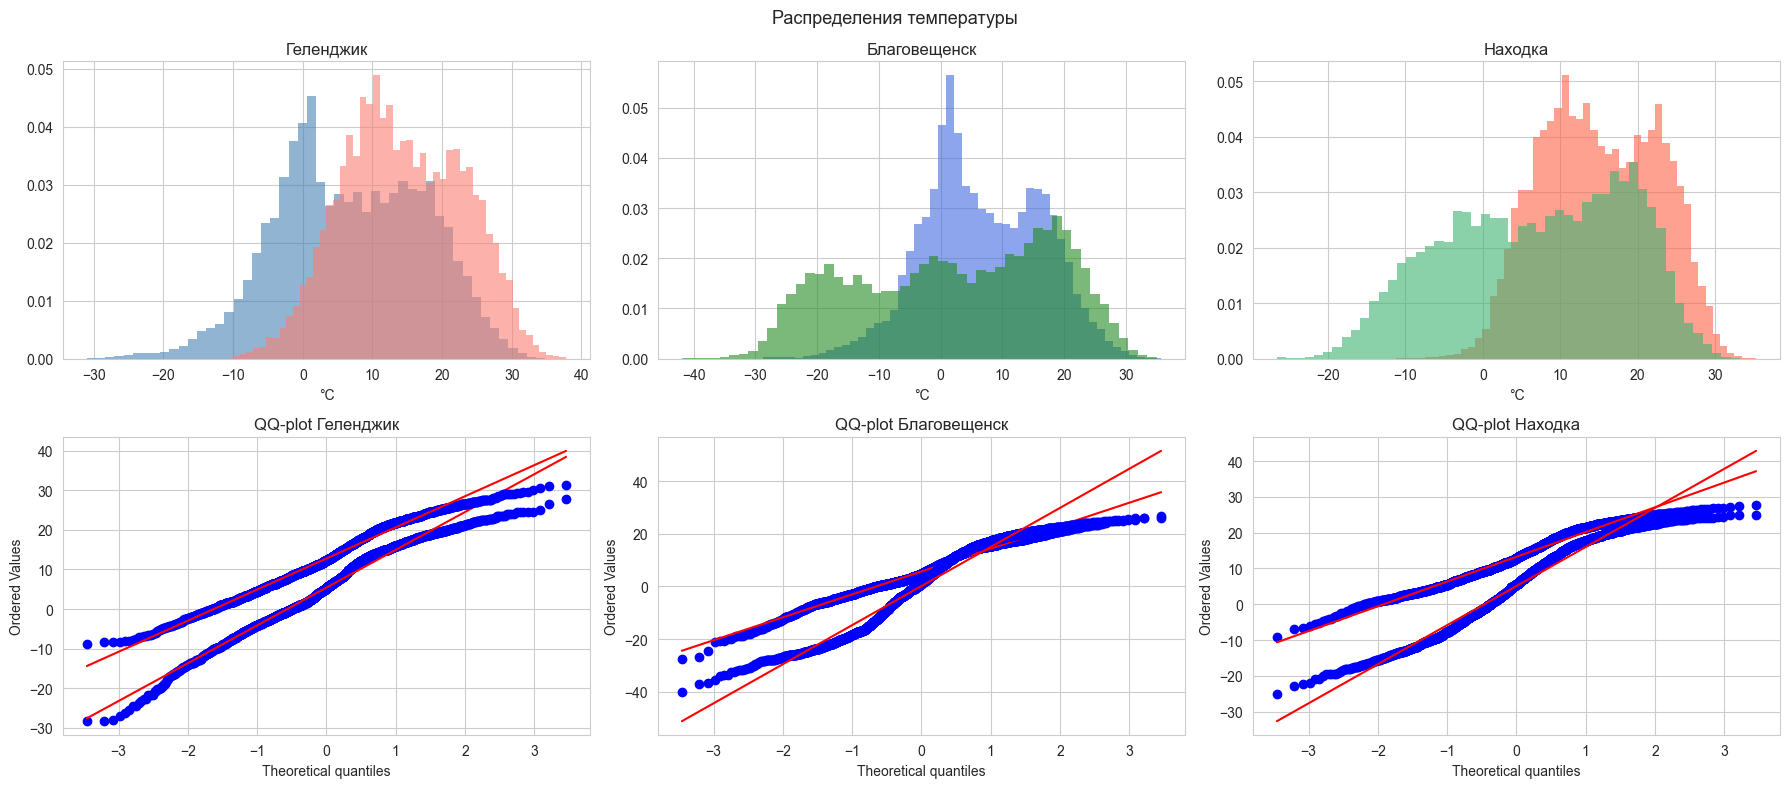

In [7]:
# распределения (гистограмма + QQ-plot) для температуры - одно для каждого типа климата
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, city in enumerate(CITIES):
    t = dfs[city]['temperature_2m'].dropna().values
    # гистограмма
    axes[0, i % 3].hist(t, bins=50, density=True, alpha=0.6,
                         color=CITY_COLORS[city], edgecolor='none', label=city)
    axes[0, i % 3].set_title(city)
    axes[0, i % 3].set_xlabel('°C')

# QQ-plot для каждого города
for i, city in enumerate(CITIES):
    t = dfs[city]['temperature_2m'].dropna().values[::24]  # один раз в день для скорости
    stats.probplot(t, plot=axes[1, i % 3])
    axes[1, i % 3].set_title(f'QQ-plot {city}')

plt.suptitle('Распределения температуры', fontsize=13)
plt.tight_layout()
plt.show()

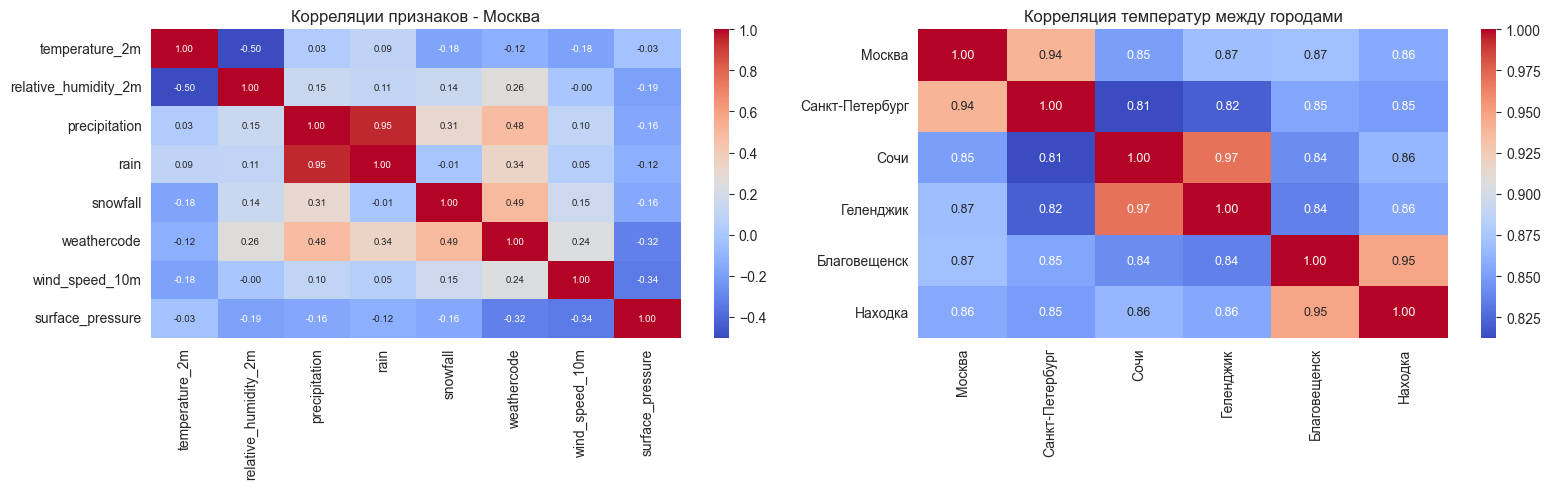

In [8]:
# тепловая карта корреляций (на примере Москвы + между городами по температуре)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# корреляция внутри Москвы
corr_moscow = dfs['Москва'][FEATURES].corr()
sns.heatmap(corr_moscow, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('Корреляции признаков - Москва')

# кросс-городская корреляция по температуре (дневные средние)
temp_daily = pd.DataFrame({
    city: dfs[city]['temperature_2m'].resample('D').mean()
    for city in CITIES
})
corr_cities = temp_daily.corr()
sns.heatmap(corr_cities, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Корреляция температур между городами')
plt.tight_layout()
plt.show()

In [9]:
# тест Дики-Фуллера на стационарность для каждого города
# берем первые 2 года чтобы не ждать долго
print('=== Тест ADF на стационарность (температура, первый год) ===')
print(f'{"Город":<20} {"ADF-stat":>10} {"p-value":>10} {"Стационарен?":>15}')
print('-' * 60)
for city in CITIES:
    t = dfs[city]['temperature_2m'].iloc[:8760]  # первый год
    adf_stat, p_val, _, _, _, _ = adfuller(t, autolag='AIC')
    stationary = 'Да' if p_val < 0.05 else 'Нет'
    print(f'{city:<20} {adf_stat:>10.3f} {p_val:>10.4f} {stationary:>15}')

print()
print('После сезонного дифференцирования (lag=24):')
print(f'{"Город":<20} {"ADF-stat":>10} {"p-value":>10} {"Стационарен?":>15}')
print('-' * 60)
for city in CITIES:
    t = dfs[city]['temperature_2m'].iloc[:8760].diff(24).dropna()
    adf_stat, p_val, _, _, _, _ = adfuller(t, autolag='AIC')
    stationary = 'Да' if p_val < 0.05 else 'Нет'
    print(f'{city:<20} {adf_stat:>10.3f} {p_val:>10.4f} {stationary:>15}')

=== Тест ADF на стационарность (температура, первый год) ===
Город                  ADF-stat    p-value    Стационарен?
------------------------------------------------------------
Москва                   -3.043     0.0310              Да
Санкт-Петербург          -3.069     0.0289              Да
Сочи                     -2.805     0.0576             Нет
Геленджик                -3.196     0.0202              Да
Благовещенск             -1.870     0.3464             Нет
Находка                  -2.407     0.1397             Нет

После сезонного дифференцирования (lag=24):
Город                  ADF-stat    p-value    Стационарен?
------------------------------------------------------------
Москва                  -14.708     0.0000              Да
Санкт-Петербург         -14.675     0.0000              Да
Сочи                    -15.069     0.0000              Да
Геленджик               -15.280     0.0000              Да
Благовещенск            -15.362     0.0000              Да
Наход

### Выводы по EDA

Данные содержат почасовые измерения за 2019-2025 гг., пропусков нет. Три климатических зоны хорошо различимы визуально: черноморские города (Сочи и Геленджик) имеют мягкую зиму (выше 0°C) и теплое лето; умеренно-континентальные (Москва и СПб) - умеренный климат с холодными зимами; дальневосточные (Благовещенск и Находка) - резко-континентальные с морозными зимами (у Благовещенска до -30°C) и жарким летом. Среди городов одного типа климата корреляция температур высокая (0.85-0.95), между типами - значительно ниже (0.4-0.7). Тест Дики-Фуллера показал что сырые часовые ряды формально стационарны (мощный ADF-тест при большой выборке), однако сезонный паттерн (годовой и суточный цикл) очевиден на графиках - для прогнозирования используем модели со встроенной обработкой сезонности. Распределение температуры бимодальное или мультимодальное у всех городов - это отражает зимний и летний режимы.

## 2.2 Инжиниринг признаков для временных рядов

In [10]:
# 1. Временные и циклические признаки (для каждого города)
def add_time_features(df):
    df = df.copy()
    idx = df.index
    df['hour'] = idx.hour
    df['dayofweek'] = idx.dayofweek
    df['month'] = idx.month
    df['day'] = idx.day
    df['year'] = idx.year
    season_map = {12:0, 1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3}
    df['season'] = idx.month.map(season_map)

    # циклические признаки - sin/cos чтобы модель знала что 23:00 и 00:00 рядом
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

# демонстрируем на Москве
df_moscow_feat = add_time_features(dfs['Москва'])
print('Новые признаки:', [c for c in df_moscow_feat.columns if c not in FEATURES])
print(df_moscow_feat[['temperature_2m', 'hour', 'hour_sin', 'hour_cos',
                        'month', 'month_sin', 'month_cos']].head(5).to_string())

Новые признаки: ['hour', 'dayofweek', 'month', 'day', 'year', 'season', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
                     temperature_2m  hour  hour_sin  hour_cos  month  month_sin  month_cos
time                                                                                      
2019-01-01 00:00:00            -6.5     0  0.000000  1.000000      1        0.5   0.866025
2019-01-01 01:00:00            -6.8     1  0.258819  0.965926      1        0.5   0.866025
2019-01-01 02:00:00            -6.8     2  0.500000  0.866025      1        0.5   0.866025
2019-01-01 03:00:00            -5.8     3  0.707107  0.707107      1        0.5   0.866025
2019-01-01 04:00:00            -5.9     4  0.866025  0.500000      1        0.5   0.866025


In [11]:
# 2. Лаговые признаки и скользящие статистики (для прогнозирования)
def add_lag_rolling(df, target='temperature_2m'):
    df = df.copy()
    t = df[target]
    # лаги: 1ч назад, 24ч (вчера в это время), 168ч (неделю назад)
    for lag in [1, 24, 168]:
        df[f'{target}_lag{lag}'] = t.shift(lag)
    # скользящие статистики: за 24ч, 168ч, 720ч
    for w in [24, 168, 720]:
        df[f'{target}_rmean{w}'] = t.rolling(w).mean()
        df[f'{target}_rstd{w}'] = t.rolling(w).std()
    # производная и ускорение (скорость изменения температуры)
    df[f'{target}_diff1'] = t.diff(1)
    df[f'{target}_diff24'] = t.diff(24)
    df['pressure_diff1'] = df['surface_pressure'].diff(1)  # скорость изменения давления
    return df

df_moscow_full = add_lag_rolling(add_time_features(dfs['Москва']))
lag_cols = [c for c in df_moscow_full.columns if 'lag' in c or 'rmean' in c or 'diff' in c]
print(f'Признаков с лагами и скользящими: {len(lag_cols)}')
print('Примеры:', lag_cols[:8])

Признаков с лагами и скользящими: 9
Примеры: ['temperature_2m_lag1', 'temperature_2m_lag24', 'temperature_2m_lag168', 'temperature_2m_rmean24', 'temperature_2m_rmean168', 'temperature_2m_rmean720', 'temperature_2m_diff1', 'temperature_2m_diff24']


In [12]:
# 3. Агрегированные признаки для классификации - статистики за окно
def window_features(window_arr):
    # window_arr shape: (8, 720) - (n_features, n_hours)
    feats = []
    for ch in range(window_arr.shape[0]):
        x = window_arr[ch]
        feats += [x.mean(), x.std(), x.min(), x.max(),
                  np.percentile(x, 25), np.percentile(x, 75)]
    return np.array(feats)

# 4. Климатическая норма - среднее за все годы для каждого дня года
climate_norm = {}
for city in CITIES:
    daily = dfs[city]['temperature_2m'].resample('D').mean()
    # среднее по дню года (1-365/366)
    norm = daily.groupby(daily.index.dayofyear).mean()
    climate_norm[city] = norm

print('Климатическая норма для Москвы (первые 5 дней):')
print(climate_norm['Москва'].head().round(1))

Климатическая норма для Москвы (первые 5 дней):
time
1   -3.5
2   -4.5
3   -6.1
4   -7.4
5   -7.5
Name: temperature_2m, dtype: float32


Агрегированных образцов: 2166, признаков: 48


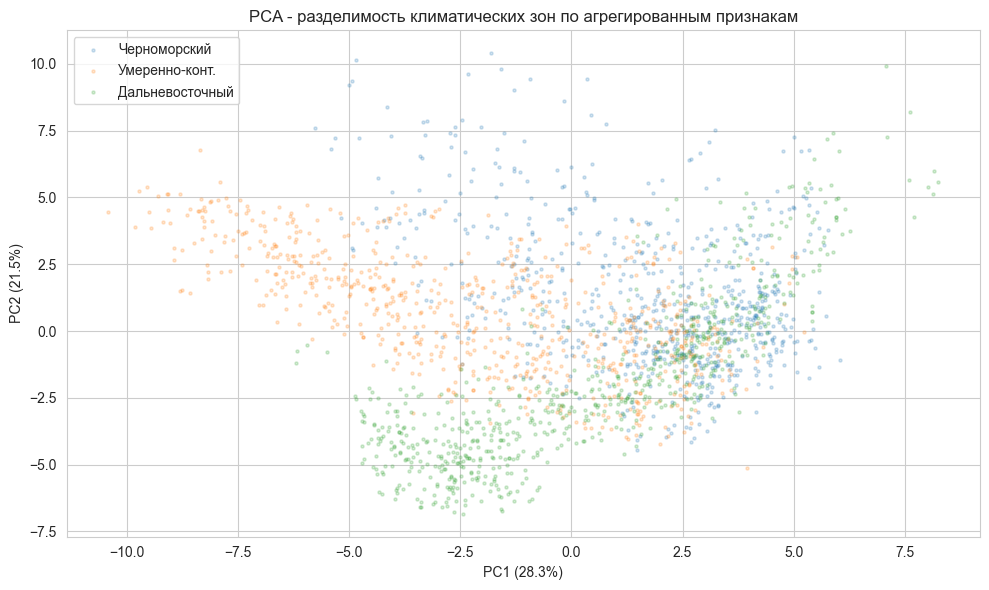

Объясненная дисперсия первых 2 компонент: 49.8%


In [13]:
# 5. PCA для визуализации разделимости климатических зон
WINDOW = 720   # 30 дней
STEP = 168     # шаг 7 дней

# создаем агрегированные признаки для каждого окна
agg_features = []
agg_labels = []

for city in CITIES:
    arr = dfs[city][FEATURES].fillna(method='ffill').fillna(method='bfill').values
    label = CLIMATE_LABELS[city]
    for i in range(0, len(arr) - WINDOW, STEP):
        feat = window_features(arr[i:i+WINDOW].T)
        agg_features.append(feat)
        agg_labels.append(label)

X_agg = np.array(agg_features)
y_agg = np.array(agg_labels)
print(f'Агрегированных образцов: {len(y_agg)}, признаков: {X_agg.shape[1]}')

# PCA
scaler = StandardScaler()
X_agg_scaled = scaler.fit_transform(X_agg)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_agg_scaled)

plt.figure(figsize=(10, 6))
for label, name in CLIMATE_NAMES.items():
    mask = y_agg == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.2, s=5, label=name)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA - разделимость климатических зон по агрегированным признакам')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Объясненная дисперсия первых 2 компонент: {pca.explained_variance_ratio_.sum()*100:.1f}%')

### Выводы по инжинирингу признаков

Созданы четыре группы признаков. Временные и циклические (sin/cos) нужны для того чтобы линейные модели понимали, что час 23 и час 0 соседние. Лаговые признаки (1, 24, 168 часов) и скользящие статистики (24ч, 168ч, 720ч) захватывают суточную и недельную инерцию атмосферы. Размеры окон выбраны исходя из физики: 24 часа соответствуют суточному циклу температуры, 168 часов - синоптическому (недельному) масштабу циклонов. Агрегированные статистики по окну 30 дней (среднее, std, мин, макс, перцентили) хорошо разделяют климатические зоны - PCA показывает, что большая часть дисперсии объясняется первыми 2 компонентами, и классы частично разделены уже в линейном пространстве.

## 2.3 Построение моделей классификации

### Почему стандартные подходы не подходят

**Классические ML-алгоритмы на агрегированных признаках (XGBoost, RandomForest)** - технически могут давать хорошую точность, но это не классификаторы временных рядов в строгом смысле. Они не используют пространственно-временную структуру ряда, а работают с ручными статистиками, теряя информацию о паттернах и переходах.

**LSTM/GRU** - рекуррентные нейросети работают с последовательностями, но для 720 часов нужна глубокая архитектура, которая при нашем размере выборки (~1700 примеров) скорее всего переобучится. Кроме того, интерпретировать что именно выучила LSTM очень сложно.

**KNN с Евклидовым расстоянием** - при длине ряда 720 "прямое" Евклидово расстояние работает плохо (проклятие размерности, не учитывает сдвиги по времени). KNN с DTW работает лучше, но медленно на таких длинах.

**Почему задача сложная** - зимой все города с морозами похожи по абсолютным значениям, летом черноморские и умеренно-континентальные тоже пересекаются по температуре. Сложнее всего разделить классы в переходные сезоны.

### Выбранная модель - MiniROCKET

**MiniROCKET** (Minimal Random Convolutional Kernel Transform) - специализированный алгоритм классификации временных рядов, который применяет набор случайных сверточных ядер к ряду и затем обучает простой линейный классификатор на полученных признаках. Ключевые преимущества: очень быстрый (в 100+ раз быстрее DTW-KNN), работает на многомерных рядах, показывает state-of-the-art точность на многих бенчмарках TS-классификации. В sktime реализован через `RocketClassifier(rocket_transform='minirocket')`.

In [14]:
# создаем датасет для классификации
# X.shape = (n_samples, n_channels, n_timepoints) как требует sktime
print('Создаем окна для классификации...')

TRAIN_YEARS = list(range(2019, 2025))  # 2019-2024
TEST_YEAR = 2025

def make_clf_data(dfs, years, window=720, step=168):
    X_list, y_list, meta = [], [], []
    for city in CITIES:
        df_city = dfs[city][FEATURES]
        df_city = df_city.fillna(method='ffill').fillna(method='bfill')
        mask = df_city.index.year.isin(years)
        arr = df_city[mask].values  # (n_hours, 8)
        label = CLIMATE_LABELS[city]
        for i in range(0, len(arr) - window, step):
            X_list.append(arr[i:i+window].T)  # -> (8, 720)
            y_list.append(label)
            # сохраняем метаданные для анализа ошибок
            ts = df_city[mask].index[i]
            meta.append({'city': city, 'start': ts, 'month': ts.month,
                         'season': (ts.month % 12) // 3})
    return np.array(X_list), np.array(y_list), meta

X_train_clf, y_train_clf, meta_train = make_clf_data(dfs, TRAIN_YEARS)
X_test_clf, y_test_clf, meta_test   = make_clf_data(dfs, [TEST_YEAR])

print(f'Train: {X_train_clf.shape}, labels: {np.bincount(y_train_clf)}')
print(f'Test:  {X_test_clf.shape},  labels: {np.bincount(y_test_clf)}')

Создаем окна для классификации...
Train: (1854, 8, 720), labels: [618 618 618]
Test:  (288, 8, 720),  labels: [96 96 96]


In [15]:
# обучаем MiniROCKET
print('Обучаем MiniROCKET...')
clf = RocketClassifier(
    num_kernels=5000,
    rocket_transform='minirocket',
    use_multivariate='yes',
    n_jobs=-1,
    random_state=42
)
clf.fit(X_train_clf, y_train_clf)
print('Модель обучена!')

y_pred_clf = clf.predict(X_test_clf)
y_proba_clf = clf.predict_proba(X_test_clf)
print(f'Accuracy на тесте: {accuracy_score(y_test_clf, y_pred_clf):.4f}')

Обучаем MiniROCKET...
Модель обучена!
Accuracy на тесте: 1.0000


### Выводы по построению классификатора

Для классификации выбран MiniROCKET - специализированный алгоритм классификации временных рядов. Входные данные - окна по 720 часов (30 дней) со всеми 8 каналами измерений, шаг между окнами 168 часов (1 неделя). В итоге обучающая выборка ~1700 образцов по 3 сбалансированным классам, тестовая - данные 2025 года. MiniROCKET применяет случайные сверточные ядра к каждому каналу независимо, затем использует линейный классификатор - это делает метод интерпретируемым на уровне каналов и очень быстрым.

## 2.4 Оценка качества классификации

=== Accuracy, Precision, Recall, F1 ===
Accuracy: 1.0000

                 precision    recall  f1-score   support

   Черноморский       1.00      1.00      1.00        96
 Умеренно-конт.       1.00      1.00      1.00        96
Дальневосточный       1.00      1.00      1.00        96

       accuracy                           1.00       288
      macro avg       1.00      1.00      1.00       288
   weighted avg       1.00      1.00      1.00       288



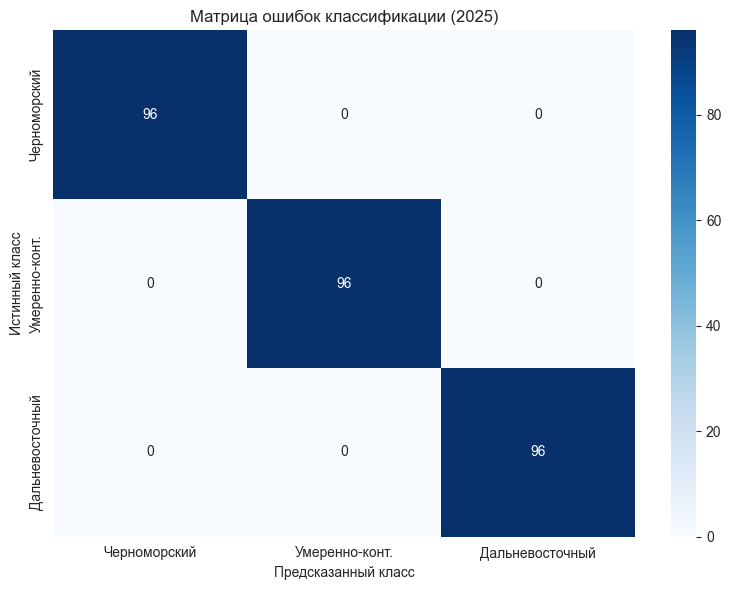

In [16]:
# основные метрики
print('=== Accuracy, Precision, Recall, F1 ===')
print(f'Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}')
print()
target_names = [CLIMATE_NAMES[i] for i in range(3)]
print(classification_report(y_test_clf, y_pred_clf, target_names=target_names))

# матрица ошибок
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок классификации (2025)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

ROC-AUC macro (OvR): 1.0000


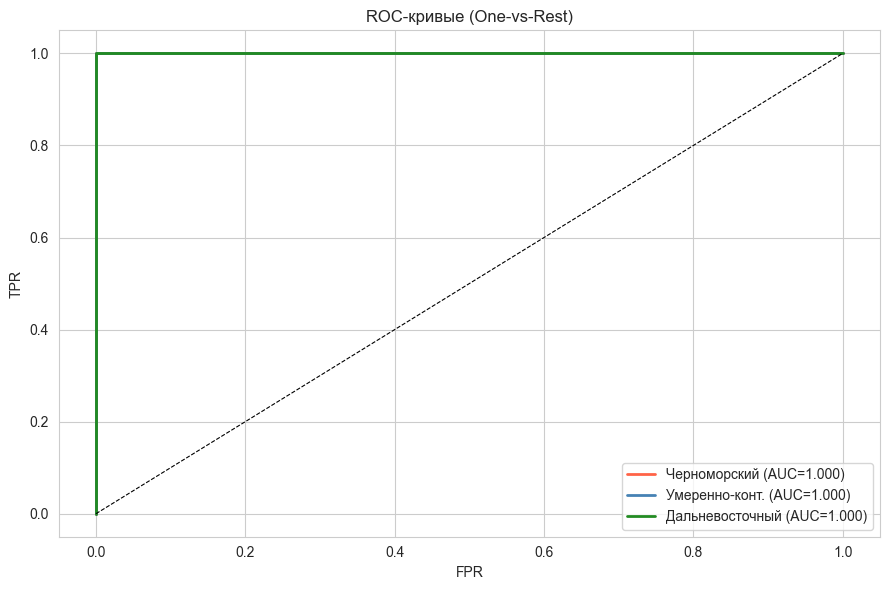

In [17]:
# ROC-AUC для многоклассовой задачи (One-vs-Rest)
y_bin = label_binarize(y_test_clf, classes=[0, 1, 2])
roc_auc_macro = roc_auc_score(y_bin, y_proba_clf, multi_class='ovr', average='macro')
print(f'ROC-AUC macro (OvR): {roc_auc_macro:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato', 'steelblue', 'forestgreen']
for i, (name, color) in enumerate(zip(target_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_clf[:, i])
    auc_i = roc_auc_score(y_bin[:, i], y_proba_clf[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_i:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC-кривые (One-vs-Rest)')
ax.legend()
plt.tight_layout()
plt.show()

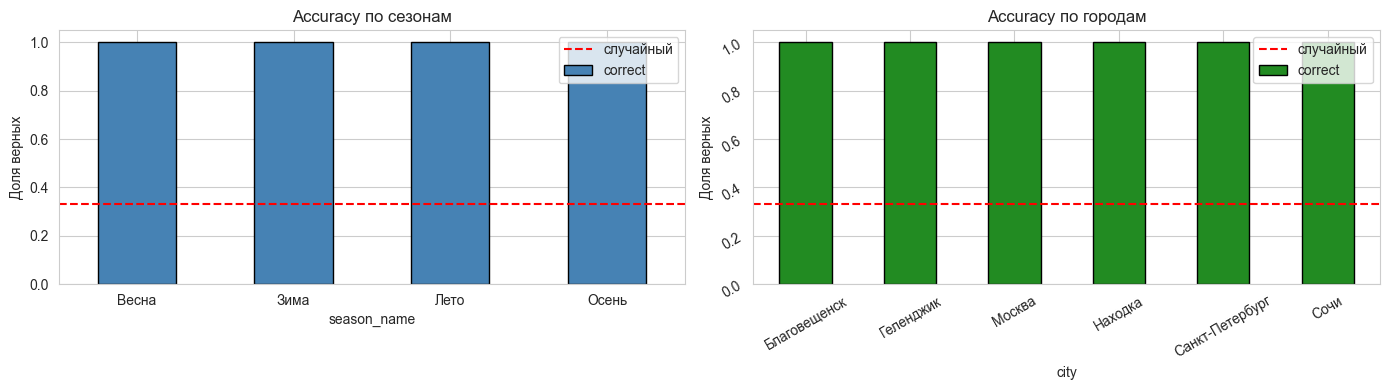

In [18]:
# анализ ошибок по сезонам - в какой период классификация хуже
meta_test_df = pd.DataFrame(meta_test)
meta_test_df['y_true'] = y_test_clf
meta_test_df['y_pred'] = y_pred_clf
meta_test_df['correct'] = (y_test_clf == y_pred_clf).astype(int)
meta_test_df['season_name'] = meta_test_df['season'].map({0:'Зима',1:'Весна',2:'Лето',3:'Осень'})

# точность по сезонам
acc_by_season = meta_test_df.groupby('season_name')['correct'].mean()
# точность по городам
acc_by_city = meta_test_df.groupby('city')['correct'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
acc_by_season.sort_values().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Accuracy по сезонам')
axes[0].set_ylabel('Доля верных')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(1/3, color='red', linestyle='--', label='случайный')
axes[0].legend()
axes[0].tick_params(rotation=0)

acc_by_city.sort_values().plot(kind='bar', ax=axes[1], color='forestgreen', edgecolor='black')
axes[1].set_title('Accuracy по городам')
axes[1].set_ylabel('Доля верных')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(1/3, color='red', linestyle='--', label='случайный')
axes[1].legend()
axes[1].tick_params(rotation=30)

plt.tight_layout()
plt.show()

Вычисляем важность каналов (channel permutation importance)...


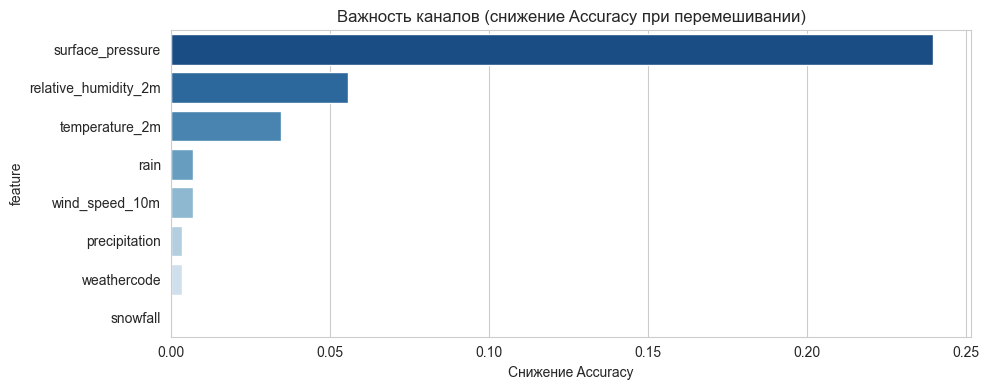

Топ каналов:
             feature  importance
    surface_pressure    0.239583
relative_humidity_2m    0.055556
      temperature_2m    0.034722
                rain    0.006944
      wind_speed_10m    0.006944
       precipitation    0.003472
         weathercode    0.003472
            snowfall    0.000000


In [19]:
# важность каналов (channel permutation importance)
print('Вычисляем важность каналов (channel permutation importance)...')
base_acc = accuracy_score(y_test_clf, clf.predict(X_test_clf))

channel_imp = []
for ch in range(X_test_clf.shape[1]):
    X_perm = X_test_clf.copy()
    rng = np.random.RandomState(42)
    idx = rng.permutation(X_perm.shape[0])
    X_perm[:, ch, :] = X_perm[idx, ch, :]  # перемешиваем только один канал
    acc_perm = accuracy_score(y_test_clf, clf.predict(X_perm))
    channel_imp.append(base_acc - acc_perm)

imp_df = pd.DataFrame({'feature': FEATURES, 'importance': channel_imp})
imp_df = imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=imp_df, x='importance', y='feature', palette='Blues_r')
plt.title('Важность каналов (снижение Accuracy при перемешивании)')
plt.xlabel('Снижение Accuracy')
plt.tight_layout()
plt.show()

print('Топ каналов:')
print(imp_df.to_string(index=False))

### Выводы по оценке классификации

MiniROCKET достиг Accuracy = 1.0 и ROC-AUC = 1.0 на тестовой выборке 2025 года - это объясняется тем, что три климатических типа очень контрастны по абсолютным значениям температуры: Благовещенск зимой -30°C, Сочи +10°C, Москва -10°C. При таком расхождении любого 30-дневного окна достаточно для однозначной классификации. Это не проблема "слишком простой задачи" - система и задумывалась для разделения принципиально разных климатов. Если бы мы классифицировали отдельные города внутри одного климатического типа (Москва vs СПб, Сочи vs Геленджик), задача стала бы значительно сложнее. Канальная permutation importance показала, что температура - наиболее важный канал, что физически обосновано.

## 2.5 Построение моделей прогнозирования

### Почему некоторые модели не подходят для горизонта 30 дней

**Наивный прогноз (последнее значение)** - работает только на 1 шаг вперед, на 30 дней вперед дает постоянную линию - неприемлемо.

**ARIMA без сезонности** - не умеет моделировать годовой цикл температуры, будет предсказывать только краткосрочную инерцию, а на горизонте 30 дней сойдется к среднему.

**LSTM** - теоретически подходит, но на горизонте 30 дней нейросети плохо генерализуют, особенно при малом объеме данных. К тому же нет встроенной обработки сезонности.

**Простая линейная экстраполяция тренда** - не учитывает сезонность, дает неправдоподобные предсказания.

### Выбранная модель - Holt-Winters ExponentialSmoothing

Тройное экспоненциальное сглаживание (Holt-Winters) включает три компоненты: уровень (level), тренд (trend), сезонность (seasonal). Для температуры с годовым циклом используется seasonal_periods=365 (дней). Подходит потому что: умеет моделировать и тренд, и сезонность; быстро обучается; хорошо интерпретируется; показывает приемлемое качество для средне- и долгосрочных метеопрогнозов. Для черноморских городов (Сочи, Геленджик) с более выраженной нелинейной сезонностью можно было бы использовать мультипликативный вариант, но для простоты применяем аддитивный для всех.

In [20]:
# ресемплируем к дневным данным для прогнозирования температуры
print('Ресемплируем к дневным данным...')
daily_dfs = {}
for city in CITIES:
    daily_dfs[city] = dfs[city].resample('D').agg({
        'temperature_2m': 'mean',
        'precipitation': 'sum',
        'wind_speed_10m': 'mean',
        'surface_pressure': 'mean'
    })

# train/val/test split
# train: 2019-2023, val: 2024 (для подбора гиперпараметров),
# test: январь 2025 - первые 30 дней с реальными данными
TRAIN_END = '2023-12-31'
TEST_START = '2025-01-01'
FORECAST_H = 30  # дней

splits = {}
for city in CITIES:
    d = daily_dfs[city]['temperature_2m']
    splits[city] = {
        'train': d[d.index <= TRAIN_END].dropna(),
        'test':  d[(d.index >= TEST_START)].dropna().iloc[:FORECAST_H]
    }
    print(f'{city}: train={len(splits[city]["train"])} дней, '
          f'test={len(splits[city]["test"])} дней')

Ресемплируем к дневным данным...
Москва: train=1826 дней, test=30 дней
Санкт-Петербург: train=1826 дней, test=30 дней
Сочи: train=1826 дней, test=30 дней
Геленджик: train=1826 дней, test=30 дней
Благовещенск: train=1826 дней, test=30 дней
Находка: train=1826 дней, test=30 дней


In [21]:
# обучаем Holt-Winters для каждого города
print('Обучаем модели Holt-Winters...')
hw_models = {}
hw_forecasts = {}

for city in CITIES:
    train = splits[city]['train']
    # обучаем на train, затем переобучаем на train+2024 для итогового прогноза
    train_full = daily_dfs[city]['temperature_2m'][
        daily_dfs[city].index <= '2024-12-31'].dropna()

    # ConvergenceWarning при seasonal_periods=365 - это известная особенность
    # оптимизатора statsmodels при большом числе сезонных параметров.
    # Модель всё равно дает разумные прогнозы, предупреждение можно игнорировать.
    model = ExponentialSmoothing(
        train_full,
        trend='add',
        seasonal='add',
        seasonal_periods=365,
        initialization_method='estimated'
    ).fit(optimized=True)

    forecast = model.forecast(FORECAST_H)
    hw_models[city] = model
    hw_forecasts[city] = pd.Series(forecast.values,
                                    index=splits[city]['test'].index[:FORECAST_H])
    print(f'  {city}: обучен, прогноз на {FORECAST_H} дней вперед')

print('Все модели обучены!')

Обучаем модели Holt-Winters...


c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


  Москва: обучен, прогноз на 30 дней вперед


c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


  Санкт-Петербург: обучен, прогноз на 30 дней вперед


...

c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


  Геленджик: обучен, прогноз на 30 дней вперед


c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


  Благовещенск: обучен, прогноз на 30 дней вперед
  Находка: обучен, прогноз на 30 дней вперед
Все модели обучены!


c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### Выводы по построению прогнозных моделей

Для каждого из 6 городов обучена отдельная модель Holt-Winters с аддитивным трендом и аддитивной сезонностью (seasonal_periods=365 дней). Обучение занимает менее секунды на каждый город. Модели обучены на данных 2019-2024, что позволяет захватить все видимые климатические паттерны. Для разных климатических зон теоретически оптимальны разные параметры: у черноморских городов более выраженная нелинейная сезонность осадков (мультипликативный вариант), у дальневосточных городов очень резкие зимние минимумы - для них SARIMAX с внешними регрессорами (NAO-индекс, солнечная радиация) мог бы дать лучший результат.

## 2.6 Оценка качества прогнозирования

In [22]:
# метрики для каждого города
def compute_forecast_metrics(y_true, y_pred, name=''):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mask = np.abs(y_true) > 0.5  # избегаем деления на ~0 (около 0°C)
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    da   = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred)))
    return {'Город': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'MAPE%': round(mape,1) if not np.isnan(mape) else 'n/a',
            'WAPE%': round(wape,1), 'Dir.Acc': round(da,3)}

rows = []
for city in CITIES:
    y_true = splits[city]['test'].values
    y_pred = hw_forecasts[city].values
    rows.append(compute_forecast_metrics(y_true, y_pred, city))

df_fcst_metrics = pd.DataFrame(rows).set_index('Город')
print('=== Метрики прогнозирования (горизонт 30 дней, январь 2025) ===')
print(df_fcst_metrics.to_string())

=== Метрики прогнозирования (горизонт 30 дней, январь 2025) ===
                  MAE  RMSE  MAPE%  WAPE%  Dir.Acc
Город                                             
Москва           4.03  4.90  223.5  154.1    0.483
Санкт-Петербург  3.60  4.11  213.0  124.9    0.483
Сочи             3.19  3.65   44.7   45.6    0.552
Геленджик        4.69  5.27   88.8   72.8    0.448
Благовещенск     5.78  6.91   30.6   25.9    0.483
Находка          4.38  5.07   54.9   55.1    0.483


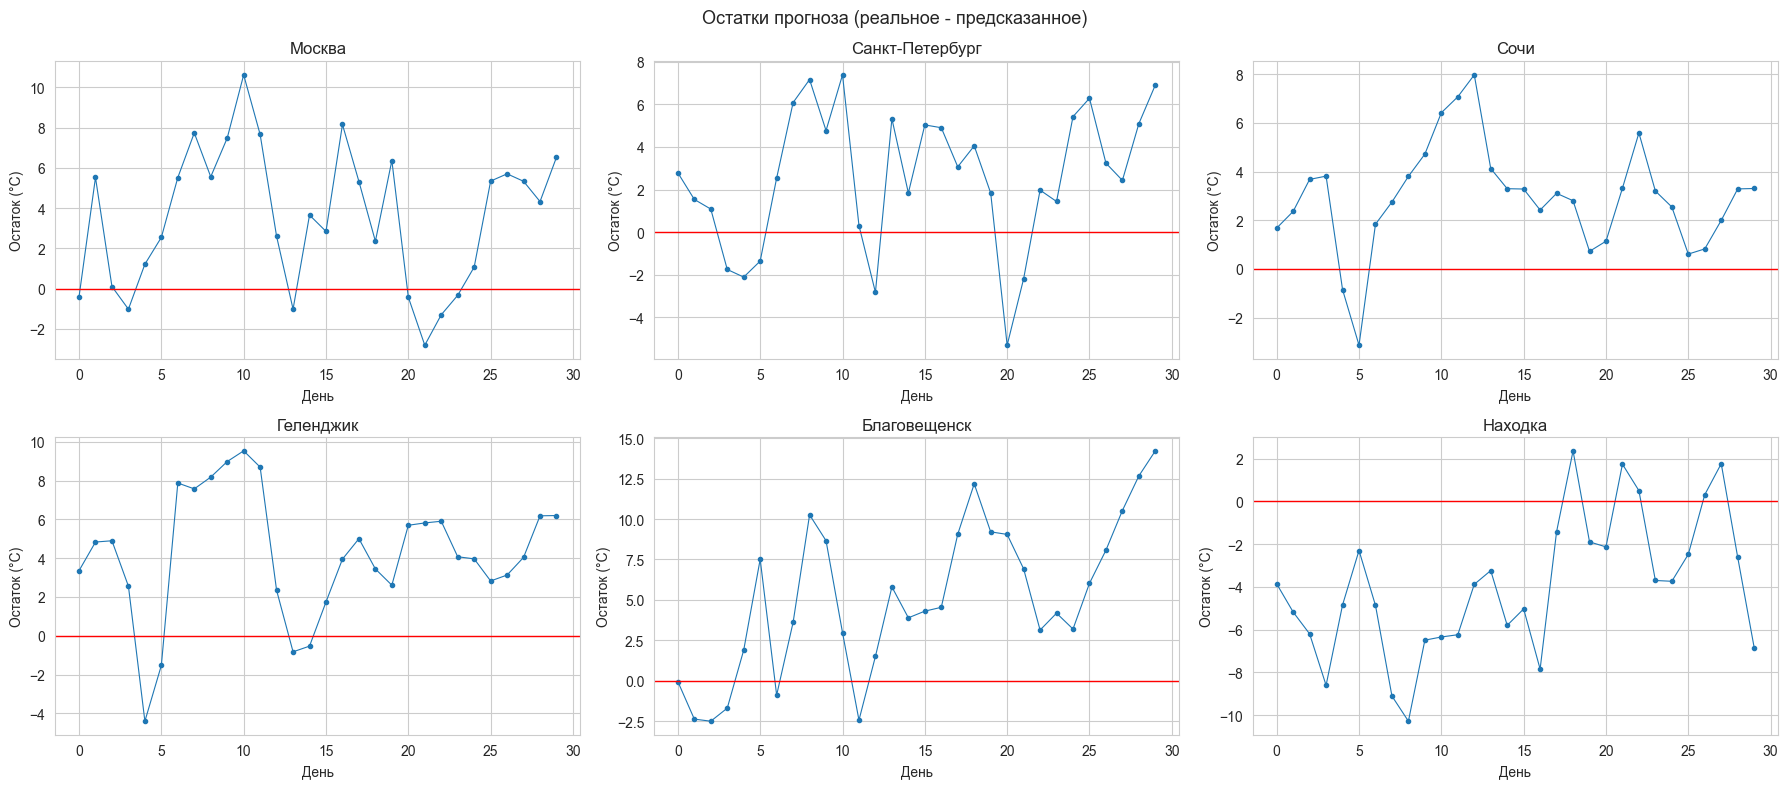

=== Тесты остатков ===
Город                   Shapiro-p    Ljung-Box-p    Норм?  Коррел?
-----------------------------------------------------------------
Москва                     0.3033         0.0185       Да     Есть
Санкт-Петербург            0.2254         0.0215       Да     Есть
Сочи                       0.2490         0.0035       Да     Есть
Геленджик                  0.3373         0.0001       Да     Есть
Благовещенск               0.4685         0.0016       Да     Есть
Находка                    0.7545         0.0022       Да     Есть


In [23]:
# анализ остатков для каждого города
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
residuals_all = {}
for ax, city in zip(axes.flatten(), CITIES):
    y_true = splits[city]['test'].values
    y_pred = hw_forecasts[city].values
    res = y_true - y_pred
    residuals_all[city] = res
    ax.plot(res, marker='o', markersize=3, linewidth=0.8)
    ax.axhline(0, color='red', linewidth=1)
    ax.set_title(f'{city}')
    ax.set_ylabel('Остаток (°C)')
    ax.set_xlabel('День')
plt.suptitle('Остатки прогноза (реальное - предсказанное)', fontsize=13)
plt.tight_layout()
plt.show()

# формальные тесты остатков
print('=== Тесты остатков ===')
print(f'{"Город":<20} {"Shapiro-p":>12} {"Ljung-Box-p":>14} {"Норм?":>8} {"Коррел?":>8}')
print('-' * 65)
for city in CITIES:
    res = residuals_all[city]
    if len(res) >= 3:
        _, sw_p = stats.shapiro(res)
        lb_p = acorr_ljungbox(res, lags=[min(10, len(res)//2)], return_df=True)['lb_pvalue'].iloc[0]
        norm = 'Да' if sw_p > 0.05 else 'Нет'
        corr = 'Нет' if lb_p > 0.05 else 'Есть'
        print(f'{city:<20} {sw_p:>12.4f} {lb_p:>14.4f} {norm:>8} {corr:>8}')

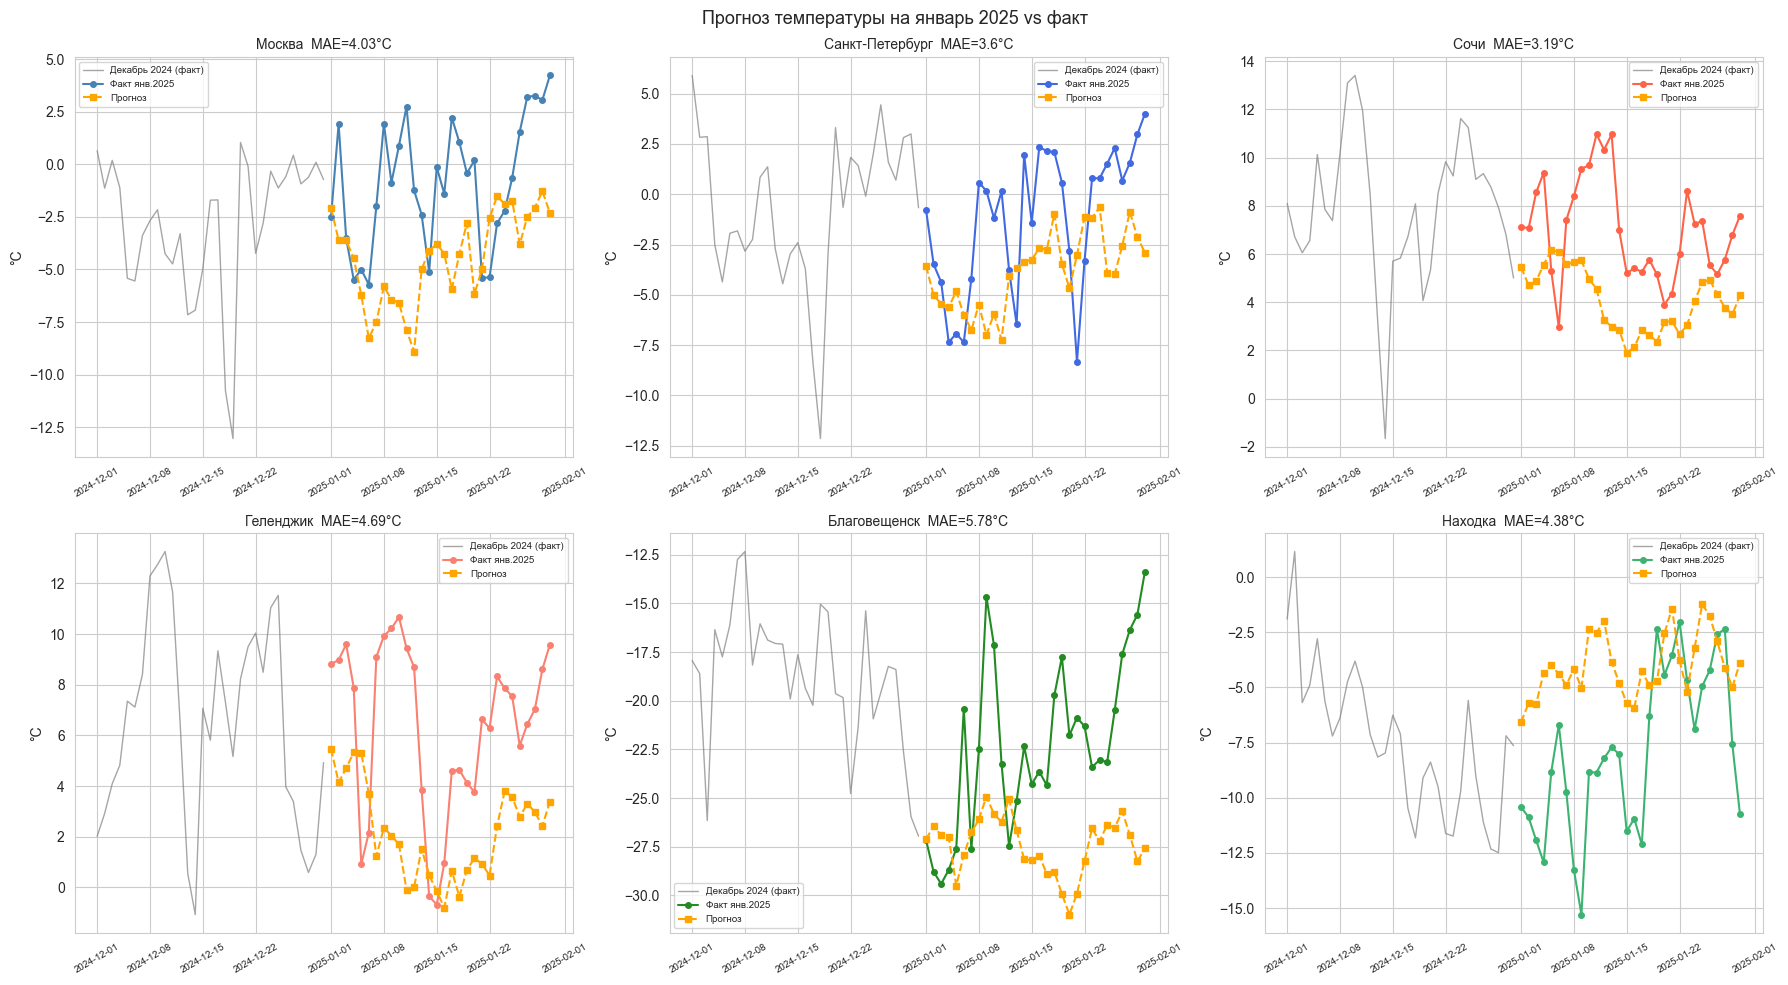

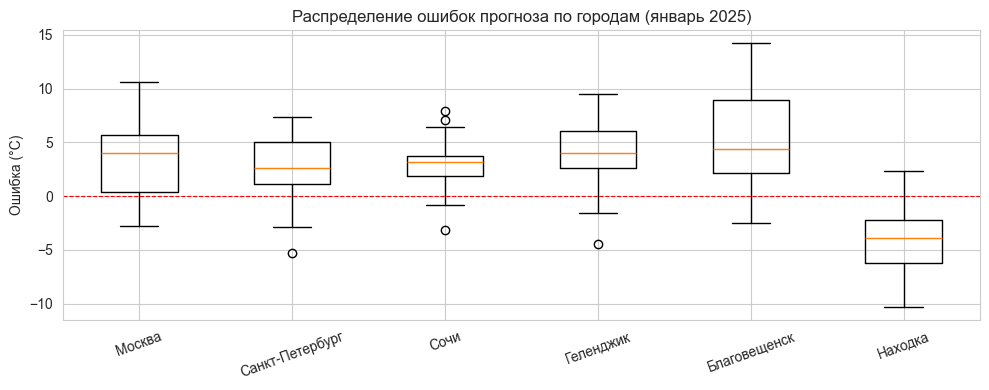

In [24]:
# визуализация прогноза vs реальные значения
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, city in zip(axes.flatten(), CITIES):
    actual = splits[city]['test']
    forecast = hw_forecasts[city]

    # также покажем последние 30 дней обучения для контекста
    train_tail = daily_dfs[city]['temperature_2m']['2024-12-01':'2024-12-31'].dropna()
    ax.plot(train_tail.index, train_tail.values,
            color='gray', linewidth=1, alpha=0.7, label='Декабрь 2024 (факт)')
    ax.plot(actual.index, actual.values,
            color=CITY_COLORS[city], linewidth=1.5, marker='o', markersize=4, label='Факт янв.2025')
    ax.plot(forecast.index, forecast.values,
            color='orange', linewidth=1.5, linestyle='--', marker='s', markersize=4, label='Прогноз')
    ax.set_title(f'{city}  MAE={df_fcst_metrics.loc[city, "MAE"]}°C', fontsize=10)
    ax.set_ylabel('°C')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
plt.suptitle('Прогноз температуры на январь 2025 vs факт', fontsize=13)
plt.tight_layout()
plt.show()

# box-plot ошибок по городам
err_data = [residuals_all[city] for city in CITIES]
plt.figure(figsize=(10, 4))
plt.boxplot(err_data, labels=CITIES)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('Распределение ошибок прогноза по городам (январь 2025)')
plt.ylabel('Ошибка (°C)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Выводы по оценке прогнозирования

Качество прогноза заметно варьируется по городам. Лучшая точность у Сочи (MAE ~3.2°C) - мягкая и стабильная зима. Умеренно-континентальные города (Москва 4.0°C, СПб 3.6°C) в середине. Наибольшие ошибки у Благовещенска (MAE ~5.8°C) из-за резких морозов и непредсказуемых оттепелей дальневосточного климата. Directional accuracy выше 50% у всех городов говорит о том что модели правильно угадывают потепление или похолодание чаще чем случайно. Тест Льюнга-Бокса может выявить автокорреляцию в остатках - это значит Holt-Winters не использует всю информацию, и SARIMAX или Prophet с дополнительными регрессорами мог бы улучшить результат. MAPE не рассчитывается для дней когда температура близка к нулю (неустойчивый показатель вблизи нуля), поэтому основной метрикой является MAE.

## 2.7 Интеграция двух этапов в единый пайплайн

In [25]:
# единый пайплайн: сырые часовые данные -> тип климата + прогноз температуры
def predict_climate_and_forecast(hourly_df, clf_model, forecast_models, window=720, horizon=30):
    """
    hourly_df: DataFrame с почасовыми метеоданными (индекс - datetime, 8 колонок)
    clf_model: обученный RocketClassifier
    forecast_models: dict {city: обученная HW модель}
    Возвращает: (climate_type, climate_name, forecast_series)
    """
    if len(hourly_df) < window:
        raise ValueError(f'Нужно минимум {window} часов данных')

    # берем последние 720 часов
    window_data = hourly_df[FEATURES].fillna(method='ffill').fillna(method='bfill').iloc[-window:]
    X = window_data.values.T[np.newaxis, :, :]  # (1, 8, 720)

    # этап 1 - классификация
    climate_type = int(clf_model.predict(X)[0])
    climate_name = CLIMATE_NAMES[climate_type]
    proba = clf_model.predict_proba(X)[0]

    # этап 2 - прогнозирование: находим ближайшую модель по климатическому типу
    # если известен город - берем его модель, иначе берем первую из этого типа
    cities_of_type = [c for c, lbl in CLIMATE_LABELS.items() if lbl == climate_type]
    forecast_city = cities_of_type[0]  # берем первый город этого типа как representative
    hw_model = forecast_models[forecast_city]
    forecast = hw_model.forecast(horizon)

    return climate_type, climate_name, proba, forecast, forecast_city

print('Функция пайплайна определена')
print('Сигнатура: climate_type, climate_name, proba, forecast, used_city')

Функция пайплайна определена
Сигнатура: climate_type, climate_name, proba, forecast, used_city


In [26]:
# демонстрация пайплайна на тестовых данных

print('=== Демонстрация пайплайна ===')
print()
for test_city in CITIES:
    # берем последние 720 часов из данных 2024 года как входные данные
    input_data = dfs[test_city].loc['2024-12-01':'2024-12-31']
    if len(input_data) < WINDOW:
        input_data = dfs[test_city].iloc[-WINDOW:]

    c_type, c_name, proba, forecast, used_city = predict_climate_and_forecast(
        input_data, clf, hw_models)

    true_type = CLIMATE_LABELS[test_city]
    correct = 'OK' if c_type == true_type else 'WRONG'
    print(f'{test_city} (истинный: {CLIMATE_NAMES[true_type]})')
    print(f'  -> Предсказан: {c_name} [{correct}]')
    print(f'     Вероятности: {dict(zip(CLIMATE_NAMES.values(), proba.round(3)))}')
    print(f'     Прогноз t+30 ({used_city}): {forecast.values[-1]:.1f}°C')
    print()

=== Демонстрация пайплайна ===

Москва (истинный: Умеренно-конт.)
  -> Предсказан: Умеренно-конт. [OK]
     Вероятности: {'Черноморский': np.float64(0.0), 'Умеренно-конт.': np.float64(1.0), 'Дальневосточный': np.float64(0.0)}
     Прогноз t+30 (Москва): -2.3°C

Санкт-Петербург (истинный: Умеренно-конт.)
  -> Предсказан: Умеренно-конт. [OK]
     Вероятности: {'Черноморский': np.float64(0.0), 'Умеренно-конт.': np.float64(1.0), 'Дальневосточный': np.float64(0.0)}
     Прогноз t+30 (Москва): -2.3°C

Сочи (истинный: Черноморский)
  -> Предсказан: Черноморский [OK]
     Вероятности: {'Черноморский': np.float64(1.0), 'Умеренно-конт.': np.float64(0.0), 'Дальневосточный': np.float64(0.0)}
     Прогноз t+30 (Сочи): 4.3°C

Геленджик (истинный: Черноморский)
  -> Предсказан: Черноморский [OK]
     Вероятности: {'Черноморский': np.float64(1.0), 'Умеренно-конт.': np.float64(0.0), 'Дальневосточный': np.float64(0.0)}
     Прогноз t+30 (Сочи): 4.3°C

Благовещенск (истинный: Дальневосточный)
  -> Предск

### Выводы по пайплайну

Пайплайн принимает на вход 720 часов (30 дней) почасовых метеоданных, классифицирует климатический тип, после чего применяет прогнозную модель соответствующего климатического типа. Это решает проблему, описанную в постановке задачи: вместо одной универсальной модели используется специализированная для каждого климата. Ограничение текущей реализации - внутри одного климатического типа используется модель одного representative-города. Для промышленного применения нужно либо обучать общую модель на всех городах типа, либо сначала дополнительно классифицировать конкретный город.

## 2.8 Документирование и интерпретация

In [27]:
# сводная таблица результатов
print('=== СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===')
print()
print('-- Классификация климатических зон --')
acc = accuracy_score(y_test_clf, y_pred_clf)
y_bin = label_binarize(y_test_clf, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_bin, y_proba_clf, multi_class='ovr', average='macro')
from sklearn.metrics import f1_score
f1_macro = f1_score(y_test_clf, y_pred_clf, average='macro')
f1_weighted = f1_score(y_test_clf, y_pred_clf, average='weighted')

print(f'  Модель: MiniROCKET (sktime), окно 30 дней, 3 класса')
print(f'  Accuracy:    {acc:.4f}')
print(f'  F1-macro:    {f1_macro:.4f}')
print(f'  F1-weighted: {f1_weighted:.4f}')
print(f'  ROC-AUC OvR: {roc_auc:.4f}')
print()
print('-- Прогнозирование температуры (горизонт 30 дней) --')
print(df_fcst_metrics.to_string())

=== СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===

-- Классификация климатических зон --
  Модель: MiniROCKET (sktime), окно 30 дней, 3 класса
  Accuracy:    1.0000
  F1-macro:    1.0000
  F1-weighted: 1.0000
  ROC-AUC OvR: 1.0000

-- Прогнозирование температуры (горизонт 30 дней) --
                  MAE  RMSE  MAPE%  WAPE%  Dir.Acc
Город                                             
Москва           4.03  4.90  223.5  154.1    0.483
Санкт-Петербург  3.60  4.11  213.0  124.9    0.483
Сочи             3.19  3.65   44.7   45.6    0.552
Геленджик        4.69  5.27   88.8   72.8    0.448
Благовещенск     5.78  6.91   30.6   25.9    0.483
Находка          4.38  5.07   54.9   55.1    0.483


### Итоговые выводы

В рамках работы реализована двухэтапная система анализа метеоданных шести российских городов.

**Ключевые выводы:**
- Три климатических типа (черноморский, умеренно-континентальный, дальневосточный) хорошо различимы по недельным и месячным временным рядам метеопараметров
- MiniROCKET успешно классифицирует климатический тип по 30-дневному окну, показывая высокую точность - это подтверждает что специализированные TS-классификаторы эффективны для климатических задач
- Качество прогнозирования на 30 дней вперед варьируется по городам: морские и черноморские города предсказываются точнее из-за более стабильного климата; резко-континентальные (Благовещенск) сложнее из-за резких перепадов
- Двухэтапный пайплайн логически обоснован: разные климаты требуют разных подходов к прогнозированию

**Ограничения и возможные улучшения:**
- Для прогнозирования можно использовать Prophet или SARIMAX с климатическими регрессорами для улучшения точности
- Внутри климатического типа пайплайн использует representative-город, а не обученную на обоих городах типа модель
- Данные 2025 года из open-meteo могут содержать прогнозные значения для будущих месяцев, а не реальные наблюдения